In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
dataframe = pd.read_csv('../data/raw/retail_store_sales.csv')
display (dataframe)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True


In [3]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [4]:
dataframe.isnull().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64

### VALIDACION DE DUPLICADOS POR TRANSACTION ID

In [5]:
dataframe['Transaction ID'].duplicated().any()

False

### IMPUTACION DEL PRICE PER UNIT

In [6]:
mask1 = (dataframe['Price Per Unit'].isna() & dataframe['Quantity'].notna() & dataframe['Total Spent'].notna())
dataframe[mask1].head(5)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
5,TXN_7482416,CUST_09,Patisserie,NaN,NaN,10.0,200.0,Credit Card,Online,2023-11-30,NaN
11,TXN_5422631,CUST_09,Milk Products,NaN,NaN,8.0,52.0,Digital Wallet,In-store,2025-01-12,True
17,TXN_9634894,CUST_15,Milk Products,NaN,NaN,10.0,275.0,Digital Wallet,Online,2022-04-17,NaN
21,TXN_8685338,CUST_15,Milk Products,NaN,NaN,3.0,105.0,Credit Card,In-store,2023-10-29,NaN
32,TXN_1543244,CUST_20,Food,NaN,NaN,8.0,196.0,Credit Card,Online,2024-10-25,True


In [7]:
dataframe.loc[mask1, 'Price Per Unit'] = dataframe.loc[mask1, 'Total Spent'] / dataframe.loc[mask1, 'Quantity']
display (dataframe)
print(dataframe['Item'].isna().sum())
display(dataframe[dataframe['Item'].isna()].head(5))

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True


1213


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
5,TXN_7482416,CUST_09,Patisserie,NaN,20.0,10.0,200.0,Credit Card,Online,2023-11-30,NaN
7,TXN_1372952,CUST_21,Furniture,NaN,33.5,NaN,NaN,Digital Wallet,In-store,2024-04-02,True
11,TXN_5422631,CUST_09,Milk Products,NaN,6.5,8.0,52.0,Digital Wallet,In-store,2025-01-12,True
15,TXN_1809665,CUST_14,Beverages,NaN,24.5,NaN,NaN,Credit Card,In-store,2022-05-11,NaN
17,TXN_9634894,CUST_15,Milk Products,NaN,27.5,10.0,275.0,Digital Wallet,Online,2022-04-17,NaN


### IMPUTACION DEL ITEM

In [8]:
dataframe[dataframe['Item'].isna()].head()
dataframe.loc[dataframe['Item'].isna(), 'Item'] = dataframe.groupby(['Category', 'Price Per Unit'])['Item'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
print(dataframe.isna().sum())

Transaction ID         0
Customer ID            0
Category               0
Item                   0
Price Per Unit         0
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64


### IDENTIFICAR REGISTROS CON QUANTITY NULL (5%)

In [9]:
mask2 = (dataframe['Quantity'].isna() & dataframe['Total Spent'].isna())
display(dataframe[mask2])

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
7,TXN_1372952,CUST_21,Furniture,Item_20_FUR,33.5,NaN,NaN,Digital Wallet,In-store,2024-04-02,True
15,TXN_1809665,CUST_14,Beverages,Item_14_BEV,24.5,NaN,NaN,Credit Card,In-store,2022-05-11,NaN
19,TXN_4206593,CUST_01,Furniture,Item_21_FUR,35.0,NaN,NaN,Digital Wallet,Online,2025-01-13,False
25,TXN_3481599,CUST_05,Furniture,Item_24_FUR,39.5,NaN,NaN,Cash,Online,2022-09-08,False
34,TXN_1621497,CUST_06,Patisserie,Item_13_PAT,23.0,NaN,NaN,Cash,In-store,2023-02-18,NaN
...,...,...,...,...,...,...,...,...,...,...,...
12527,TXN_1069238,CUST_23,Food,Item_1_FOOD,5.0,NaN,NaN,Digital Wallet,In-store,2022-08-13,False
12552,TXN_4823896,CUST_05,Milk Products,Item_3_MILK,8.0,NaN,NaN,Cash,In-store,2022-07-21,False
12556,TXN_4397672,CUST_04,Beverages,Item_25_BEV,41.0,NaN,NaN,Credit Card,Online,2024-11-28,True
12562,TXN_7422454,CUST_07,Butchers,Item_20_BUT,33.5,NaN,NaN,Cash,Online,2023-04-15,NaN


### ESTRATEGIA: ELIMINACION DE NULOS

In [10]:
dataframe = dataframe.drop(dataframe[mask2].index)
display(dataframe)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True


### IDENTIFICAR REGISTROS CON DISCOUNT APPLIED NULL (33%)

In [11]:
df = dataframe[dataframe['Discount Applied'].isna()]
display(df)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
5,TXN_7482416,CUST_09,Patisserie,Item_11_PAT,20.0,10.0,200.0,Credit Card,Online,2023-11-30,NaN
14,TXN_2490363,CUST_09,Milk Products,Item_16_MILK,27.5,2.0,55.0,Digital Wallet,Online,2022-05-22,NaN
17,TXN_9634894,CUST_15,Milk Products,Item_16_MILK,27.5,10.0,275.0,Digital Wallet,Online,2022-04-17,NaN
20,TXN_9939063,CUST_14,Beverages,Item_7_BEV,14.0,9.0,126.0,Digital Wallet,In-store,2024-01-14,NaN
...,...,...,...,...,...,...,...,...,...,...,...
12551,TXN_3673685,CUST_08,Beverages,Item_12_BEV,21.5,10.0,215.0,Digital Wallet,Online,2024-08-20,NaN
12568,TXN_1096134,CUST_06,Food,Item_4_FOOD,9.5,8.0,76.0,Digital Wallet,In-store,2022-06-11,NaN
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN


In [12]:
# convertir columna de fecha a datetime si aún no lo está
dataframe['Transaction Date'] = pd.to_datetime(dataframe['Transaction Date'], format='%Y-%m-%d', errors='coerce')

# generar columna con el mes numérico (1–12)
dataframe['Mes'] = dataframe['Transaction Date'].dt.strftime('%m%Y')

# generar columna con el trimestre (1–4)
dataframe['Trimestre'] = (
    'Q'+
    dataframe['Transaction Date'].dt.quarter.astype(str) +
    dataframe['Transaction Date'].dt.year.astype(str)
    )

display(dataframe)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Mes,Trimestre
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True,042024,Q22024
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True,072023,Q32023
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False,102022,Q42022
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN,052022,Q22022
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False,102022,Q42022
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN,092023,Q32023
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False,082022,Q32022
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN,082024,Q32024
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True,122023,Q42023


### VALIDACION DE VALORES Y FORMATOS ESTANDAR

#### Analisis de la distribución de ventas según el medio de pago
Se valida que la distribución es casi equilibrada con una ligera tendencia al uso de EFECTIVO

In [13]:
temporal = dataframe.groupby(['Payment Method']).size().reset_index(name='Conteo')
display(temporal)

,Payment Method,Conteo
0,Cash,4103
1,Credit Card,3927
2,Digital Wallet,3941


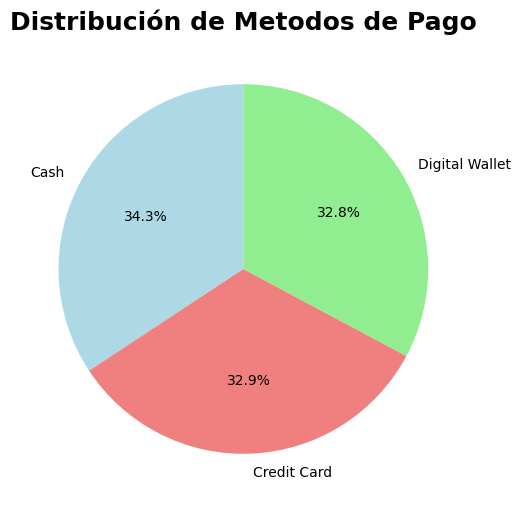

In [14]:
# Define el tamaño de la vizualización de la distribución
fig, ax = plt.subplots(figsize=(6, 6))

payment_method_counts = dataframe['Payment Method'].value_counts()

# Gráfico 1: Distribución de la variable objetivo
colors = ['lightblue', 'lightcoral', 'lightgreen']
wedges, texts, autotexts = ax.pie(payment_method_counts.values,
                                  labels=['Cash', 'Credit Card', 'Digital Wallet'],
                                  autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('Distribución de Metodos de Pago', fontsize=18, fontweight='bold')
plt.show()

#### Analisis de la distribución de ventas según la ubicación de la compra
Se valida que la distribución es casi equilibrada con una ligera tendencia a la compra PRESENCIAL

In [15]:
temporal = dataframe.groupby(['Location']).size().reset_index(name='Conteo')
display(temporal)

,Location,Conteo
0,In-store,5903
1,Online,6068


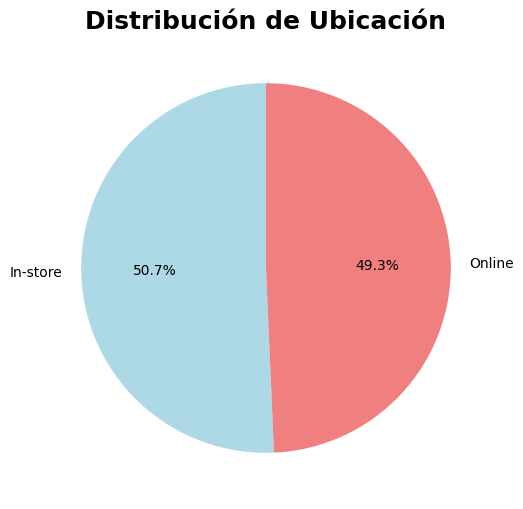

In [16]:
fig, ax = plt.subplots(figsize=(6, 6))

location_counts = dataframe['Location'].value_counts()

# Gráfico 1: Distribución de la variable objetivo
colors = ['lightblue', 'lightcoral']
wedges, texts, autotexts = ax.pie(location_counts.values,
                                  labels=['In-store', 'Online'],
                                  autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('Distribución de Ubicación', fontsize=18, fontweight='bold')
plt.show()

#### Analisis de la distribución de ventas según si aplico descuento
Se valida que la distribución es casi equilibrada con una ligera tendencia a que hay mas compras CON DESCUENTO, sin embargo el descuento no hace una diferencia marcada

In [17]:
temporal = dataframe.groupby(['Discount Applied']).size().reset_index(name='Conteo')
display(temporal)

,Discount Applied,Conteo
0,False,3964
1,True,4019


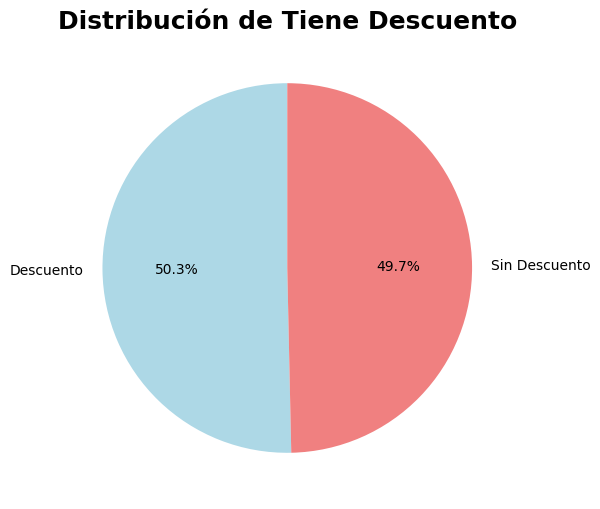

In [18]:
fig, ax = plt.subplots(figsize=(6, 6))

location_counts = dataframe['Discount Applied'].value_counts()

# Gráfico 1: Distribución de la variable objetivo
colors = ['lightblue', 'lightcoral']
wedges, texts, autotexts = ax.pie(location_counts.values,
                                  labels=['Descuento', 'Sin Descuento'],
                                  autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('Distribución de Tiene Descuento', fontsize=18, fontweight='bold')
plt.show()

#### Analisis de la distribución de ventas según Cantidad
Se valida que la distribución según cantidad predominan FURNITURE y FOOD

,Category,Quantity
5,Furniture,8462.0
4,Food,8387.0
0,Beverages,8358.0
6,Milk Products,8339.0
3,Electric household essentials,8309.0
2,Computers and electric accessories,8272.0
1,Butchers,8206.0
7,Patisserie,7943.0


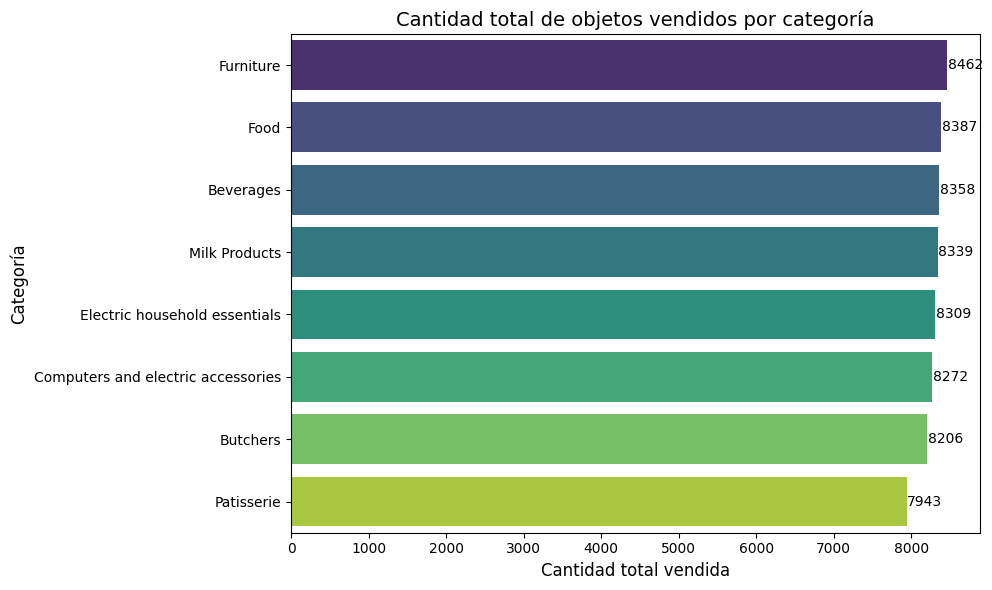

In [19]:
df_group = dataframe.groupby('Category', as_index=False)['Quantity'].sum()
df_group = df_group.sort_values('Quantity', ascending=False)
display(df_group)

plt.figure(figsize=(10,6))
sns.barplot(data=df_group, y='Category', x='Quantity', hue='Category', palette='viridis', legend=False)

# Títulos y etiquetas
plt.title('Cantidad total de objetos vendidos por categoría', fontsize=14)
plt.xlabel('Cantidad total vendida', fontsize=12)
plt.ylabel('Categoría', fontsize=12)

# Mostrar los valores sobre cada barra
for index, value in enumerate(df_group['Quantity']):
    plt.text(value + 5, index, f'{value:.0f}', va='center')

plt.tight_layout()
plt.show()

#### Analisis de la distribución de ventas según Monto
Se valida que la distribución según monto predominan BUTCHERS y ELECTRIC HOUSEHOLD ESSENTIALS

,Category,Total Spent
1,Butchers,208118.0
3,Electric household essentials,203813.5
0,Beverages,197047.5
5,Furniture,195310.0
4,Food,194812.0
2,Computers and electric accessories,190692.5
7,Patisserie,182165.5
6,Milk Products,180112.0


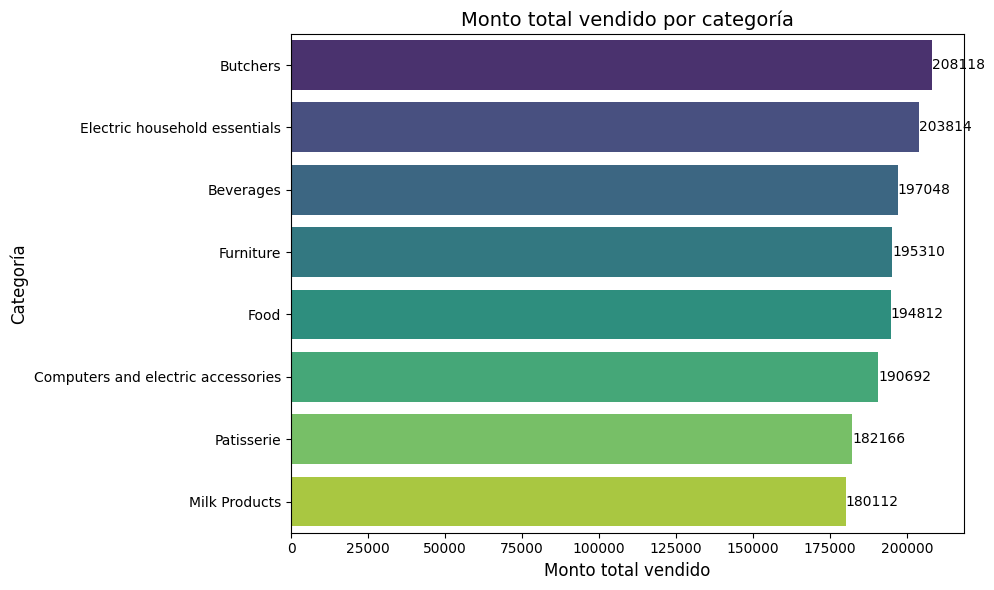

In [20]:
df_group = dataframe.groupby('Category', as_index=False)['Total Spent'].sum()
df_group = df_group.sort_values('Total Spent', ascending=False)
display(df_group)

plt.figure(figsize=(10,6))
sns.barplot(data=df_group, y='Category', x='Total Spent', hue='Category', palette='viridis', legend=False)

# Títulos y etiquetas
plt.title('Monto total vendido por categoría', fontsize=14)
plt.xlabel('Monto total vendido', fontsize=12)
plt.ylabel('Categoría', fontsize=12)

# Mostrar los valores sobre cada barra
for index, value in enumerate(df_group['Total Spent']):
    plt.text(value + 5, index, f'{value:.0f}', va='center')

plt.tight_layout()
plt.show()

In [21]:
dataframe[['Quantity', 'Price Per Unit']].describe()

,Quantity,Price Per Unit
count,11971.000000,11971.000000
mean,5.536380,23.360872
std,2.857883,10.741889
min,1.000000,5.000000
25%,3.000000,14.000000
50%,6.000000,23.000000
75%,8.000000,33.500000
max,10.000000,41.000000


Text(0.5, 1.0, 'Distribución de Venta Total')

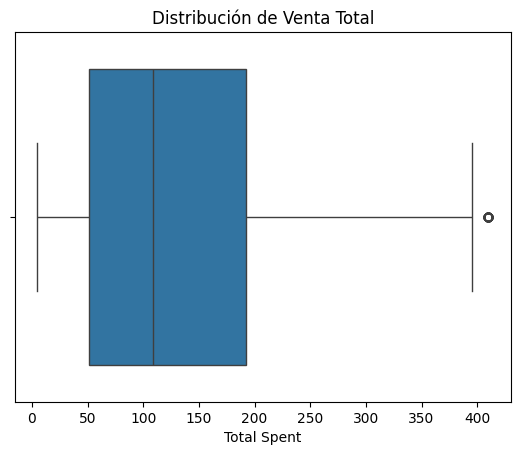

In [22]:
sns.boxplot(data = dataframe, x = 'Total Spent')
plt.title('Distribución de Venta Total')

Text(0.5, 1.0, 'Distribución de Cantidad Vendida')

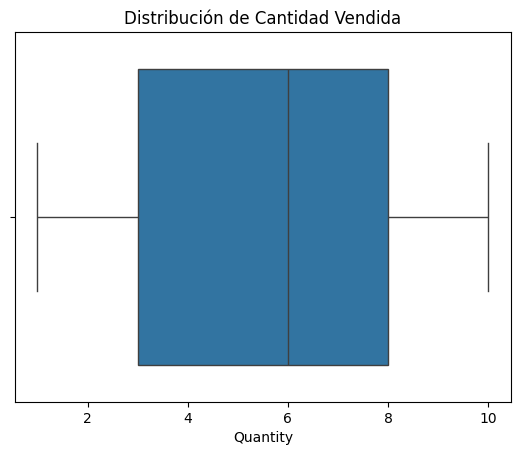

In [23]:
sns.boxplot(data = dataframe, x = 'Quantity')
plt.title('Distribución de Cantidad Vendida')

#### Analisis de la distribución de ventas según Cliente y Producto

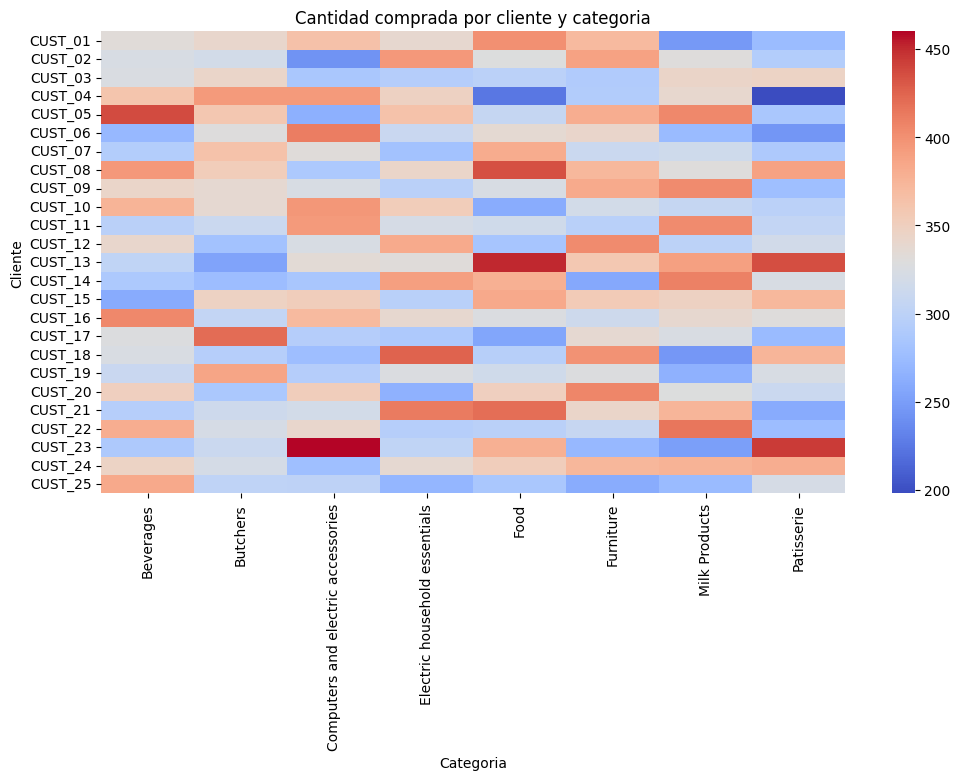

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Crear tabla dinámica: clientes vs productos (suma de cantidades)
pivot_table = dataframe.pivot_table(
    index="Customer ID",
    columns="Category",
    values="Quantity",
    aggfunc="sum",
    fill_value=0
)

# Visualizar un heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, cmap="coolwarm")
plt.title("Cantidad comprada por cliente y categoria")
plt.xlabel("Categoria")
plt.ylabel("Cliente")
plt.show()

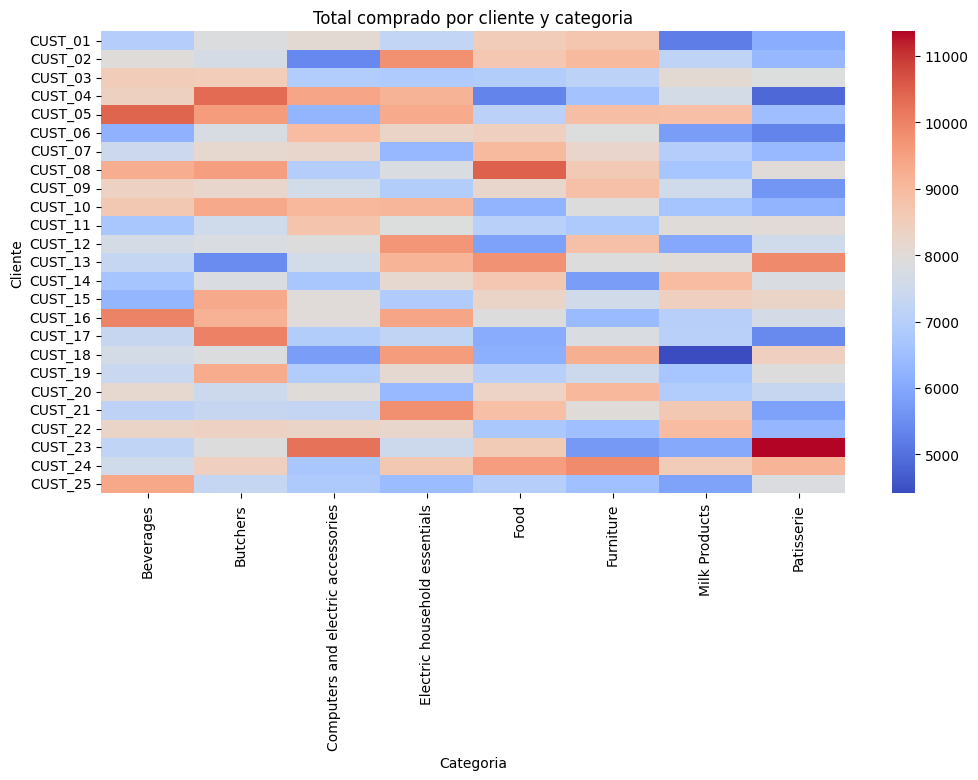

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Crear tabla dinámica: clientes vs productos (suma de cantidades)
pivot_table = dataframe.pivot_table(
    index="Customer ID",
    columns="Category",
    values="Total Spent",
    aggfunc="sum",
    fill_value=0
)

# Visualizar un heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, cmap="coolwarm")
plt.title("Total comprado por cliente y categoria")
plt.xlabel("Categoria")
plt.ylabel("Cliente")
plt.show()

### REDUCCION DE DIMENSIONALIDAD

In [26]:
dataframe2 = dataframe.drop(columns=['Transaction ID'])

### CODIFICACION DE VARIABLES

In [27]:
# Para usar una librería que categoriza columnas de forma automática
from sklearn.preprocessing import LabelEncoder

# Crear un diccionario para guardar los encoders por columna
label_encoders = {}

# Definir las columnas a excluir del LabelEncoder
excluir = ['Customer ID', 'Item', 'Mes', 'Trimestre', 'Transaction Date']

# Seleccionar solo columnas tipo object, excluyendo las que no quieres codificar
cols_a_codificar = [
    col for col in dataframe2.select_dtypes(include=["object"]).columns 
    if col not in excluir
]

# Ajustar y transformar las columnas no numéricas
for col in cols_a_codificar:
    le = LabelEncoder()
    dataframe2[col] = le.fit_transform(dataframe2[col])
    label_encoders[col] = le  # Guardar el encoder de esa columna

# Imprimir las clases encontradas para cada columna
for col, le in label_encoders.items():
    print(f"Columna: {col}")
    print(f"Clases: {list(le.classes_)}\n")

display(dataframe2)

Columna: Category
Clases: ['Beverages', 'Butchers', 'Computers and electric accessories', 'Electric household essentials', 'Food', 'Furniture', 'Milk Products', 'Patisserie']

Columna: Payment Method
Clases: ['Cash', 'Credit Card', 'Digital Wallet']

Columna: Location
Clases: ['In-store', 'Online']

Columna: Discount Applied
Clases: [False, True, nan]



,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Mes,Trimestre
0,CUST_09,7,Item_10_PAT,18.5,10.0,185.0,2,1,2024-04-08,1,042024,Q22024
1,CUST_22,6,Item_17_MILK,29.0,9.0,261.0,2,1,2023-07-23,1,072023,Q32023
2,CUST_02,1,Item_12_BUT,21.5,2.0,43.0,1,1,2022-10-05,0,102022,Q42022
3,CUST_06,0,Item_16_BEV,27.5,9.0,247.5,1,1,2022-05-07,2,052022,Q22022
4,CUST_05,4,Item_6_FOOD,12.5,7.0,87.5,2,1,2022-10-02,0,102022,Q42022
...,...,...,...,...,...,...,...,...,...,...,...,...
12570,CUST_18,7,Item_23_PAT,38.0,4.0,152.0,1,0,2023-09-03,2,092023,Q32023
12571,CUST_03,0,Item_2_BEV,6.5,9.0,58.5,0,1,2022-08-12,0,082022,Q32022
12572,CUST_11,1,Item_7_BUT,14.0,10.0,140.0,0,1,2024-08-24,2,082024,Q32024
12573,CUST_04,5,Item_7_FUR,14.0,6.0,84.0,0,1,2023-12-30,1,122023,Q42023


### RESUMEN FINAL

In [28]:
dataframe.isnull().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                   0
Price Per Unit         0
Quantity               0
Total Spent            0
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    3988
Mes                    0
Trimestre              0
dtype: int64